
### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how man
y samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



Optimized parameters: [10.28787806  4.99282165 49.89153322  0.11890548]
Minimized negative log-likelihood: 140.6461119817651


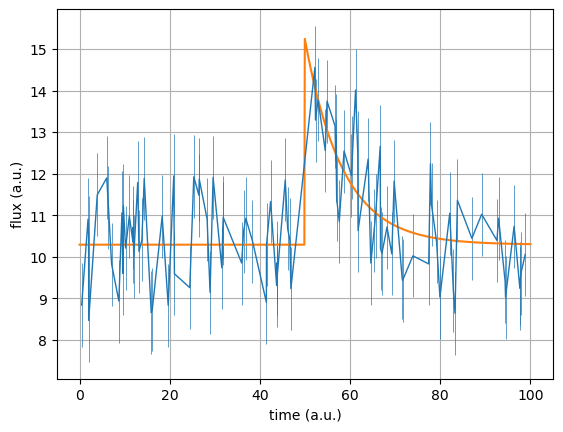

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.optimize import minimize

data_path = "/Users/albertodufour/code/astrostatistics_bicocca_2025/solutions/transient.npy"

data = np.load(data_path)

time = data[:,0]
flux = data[:,1]
flux_err = data[:,2]


plt.errorbar(time, flux, yerr=flux_err, linewidth=1, elinewidth=0.5)
plt.xlabel("time (a.u.)")
plt.ylabel("flux (a.u.)")
plt.grid(True)

#---------------- FITTING -----------------------

def model(t, b, A, t0, alpha):
    y = np.empty_like(t)
    mask = t < t0
    y[mask] = b
    y[~mask] = b + A * np.exp(-alpha * (t[~mask] - t0))
    return y


#assume gaussian likelihood
#theta = b, A, t0, alpha
def logLikelihood(flux, time, flux_err, theta):
    b, A, t0, alpha = theta
    model_flux = model(time, b, A, t0, alpha)
    sigma2 = flux_err ** 2
    return -0.5 * np.sum((flux - model_flux)**2 / sigma2 + np.log(2 * np.pi * sigma2))

#maximising the likelihood
def neg_log_likelihood(params, flux, time, flux_err):
    # b, alpha, t0, A = params  # Unpack parameters
    return -logLikelihood(flux, time, flux_err, params)

#b, A, t0, alpha
initial_guess = [10.0, 5.0, 50.0, 1/10]

fit_result = minimize(neg_log_likelihood, initial_guess, args=(flux, time, flux_err))

# Print the optimized parameters
fit_params = fit_result.x
print("Optimized parameters:", fit_params)

# Print the minimized negative log-likelihood
print("Minimized negative log-likelihood:", fit_result.fun)

#plotting
xgrid = np.linspace(0, 100, 1000)
b, alpha, t0, A = fit_result.x
plt.plot(xgrid, [model(x, b, alpha, t0, A) for x in xgrid])

plt.show()

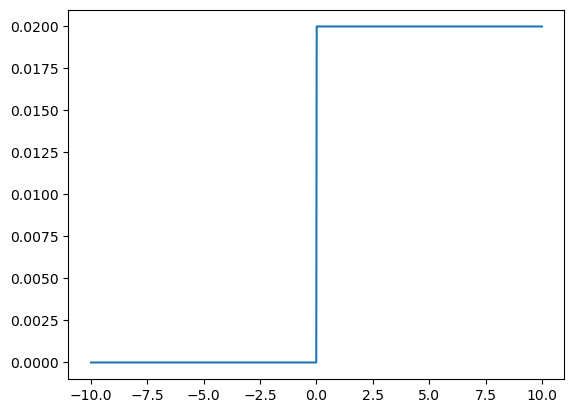

In [16]:
##testing stats.uniform

xgrid = np.linspace(-10., 10., 1000)

ygrid = stats.uniform.pdf(xgrid, loc=0., scale=50.)

plt.plot(xgrid,ygrid)

In [15]:
import numpy as np
import scipy.stats as stats
import emcee

def model(t, b, A, t0, alpha):
    y = np.empty_like(t)
    mask = t < t0
    y[mask] = b
    y[~mask] = b + A * np.exp(-alpha * (t[~mask] - t0))
    return y


# Gaussian log-likelihood
def logLikelihood(flux, time, flux_err, theta):
    b, A, t0, alpha = theta  # no transformation on alpha anymore
    model_flux = model(time, b, A, t0, alpha)
    sigma2 = flux_err ** 2
    return -0.5 * np.sum((flux - model_flux)**2 / sigma2 + np.log(2 * np.pi * sigma2))


# Log-prior (with uniform in ln_alpha)
def logPrior(theta):
    b, A, t0, alpha = theta  # no transformation on alpha anymore
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and 0 < alpha < 50:
        return 0.0
    return -np.inf


# Full log-posterior
def logPosterior(theta, time, flux, flux_err):
    lp = logPrior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(flux, time, flux_err, theta)


In [33]:
# from emcee.moves import DEMove
# move = DEMove()

ndim = 4  # number of parameters in the model
nwalkers = 64  # number of MCMC walkers
nsteps = 100000  # number of MCMC steps to take **for each walker**

# initial guess for theta
np.random.seed(0)

b_vals = np.random.normal(10, 1, nwalkers)
A_vals = np.random.normal(5, 1, nwalkers)   
t0_vals = np.random.normal(50, 1, nwalkers)  
alpha_vals = np.random.normal(0.1, 0.01, nwalkers)

p0 = np.column_stack([b_vals, A_vals, t0_vals, alpha_vals])

# Clip to the prior support
p0[:, 0] = np.clip(p0[:, 0], 0, 50)
p0[:, 1] = np.clip(p0[:, 1], 0, 50)
p0[:, 2] = np.clip(p0[:, 2], 0, 100)
p0[:, 3] = np.clip(p0[:, 3], -5, 5)

p0 += 1e-6 * np.abs(np.random.randn(*p0.shape))  # ensure linear independence

print(p0)


# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(flux, time, flux_err), threads=8)
sampler.run_mcmc(p0, nsteps, progress=True)




[[11.76405307  5.17742753 50.67229634  0.09960778]
 [10.4001584   4.59821957 50.40746243  0.08831912]
 [10.97873992  3.36980184 49.23008445  0.10523286]
 [12.24089351  5.46278235 50.53924959  0.09828731]
 [11.86755995  4.09270203 49.32566799  0.1077183 ]
 [ 9.02272261  5.05194551 50.03183259  0.10823711]
 [10.95008853  5.72909158 49.36415461  0.1216339 ]
 [ 9.84864308  5.12898352 50.67643434  0.11336649]
 [ 9.89678184  6.13940199 50.57659144  0.09630866]
 [10.41060081  3.76517524 49.79170138  0.09760735]
 [10.14404367  5.40234222 50.39600711  0.11099697]
 [11.45427481  4.31519157 48.90693861  0.10655332]
 [10.76103839  4.12920331 48.50874374  0.10640266]
 [10.12167571  4.42115049 50.43939183  0.08383152]
 [10.44386436  4.6884482  50.16667388  0.09975683]
 [10.33367437  5.05616563 50.6350315   0.0926198 ]
 [11.49407979  3.83485097 52.38314505  0.10280014]
 [ 9.79484289  5.9008268  50.94447964  0.09902075]
 [10.31306841  5.46566338 49.08717852  0.10910298]
 [ 9.14590503  3.4637575  51.11

100%|██████████| 100000/100000 [01:20<00:00, 1241.69it/s]


State([[44.78905955 20.35252872 11.94508651  0.38280914]
 [42.38076769 37.33373177  8.97164834  1.74346609]
 [42.4157022  36.79304551  8.97455874  1.69582007]
 [44.66655461 20.33329858 11.9559079   0.36812713]
 [42.47259617 36.21698625  8.98101089  1.75956765]
 [45.76507118 49.75818323  9.35257086  9.10834191]
 [44.98569066 19.6324276  11.94632751  0.37017081]
 [44.85442748 19.97524318 11.94441031  0.35416267]
 [46.35573783 49.52717058 10.05454737 48.83171687]
 [44.9917617  20.41661838 11.95036235  0.39016752]
 [24.63854553 31.37594559  8.9457337   0.12936319]
 [44.9494396  20.88639265 11.9495775   0.40828626]
 [44.98426824 20.11903213 11.94410895  0.41505375]
 [44.93621494 20.0380106  11.95183239  0.37922286]
 [44.74694966 20.29204316 11.94802169  0.39145374]
 [45.12541281 19.75231269 11.95443471  0.38767649]
 [44.86648308 20.50093699 11.94435777  0.41333417]
 [24.74032391 31.20797866  8.96247807  0.12893583]
 [45.46639917 19.4941788  11.94591036  0.38632788]
 [45.83390278 49.95374365

1150


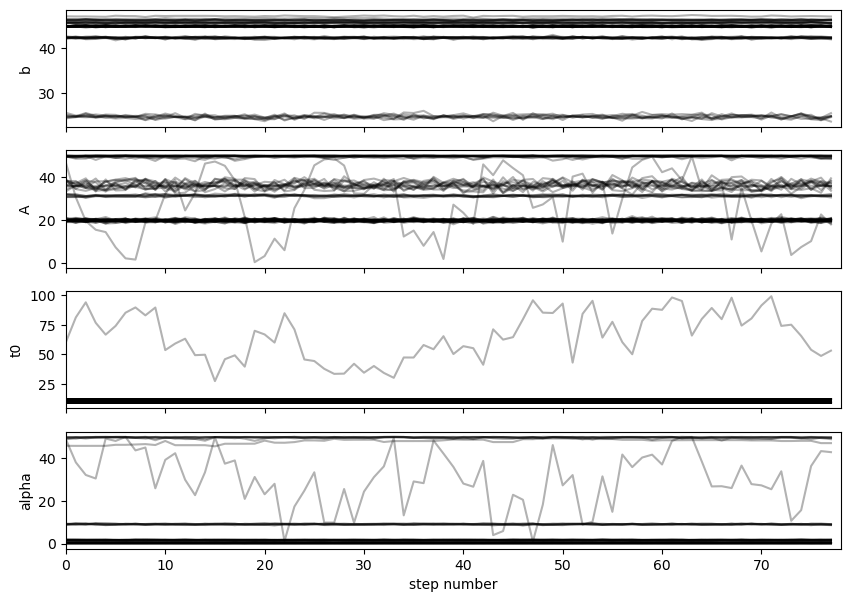

In [34]:
#BURN AND THIN
tau = sampler.get_autocorr_time()
thin = int(np.max(tau))
# thin = int(np.max(np.mean(tau)+1))
# thin = 500
burn = 10000
print(thin)

# samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
chain = sampler.get_chain(discard=burn, thin=thin)
# chain_burned = chain[burn:]
# chain_thinned = chain_burned[::thin]


#plotting
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
labels = ["b","A", "t0", "alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(chain[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(chain))
    ax.set_ylabel(labels[i])
    # ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

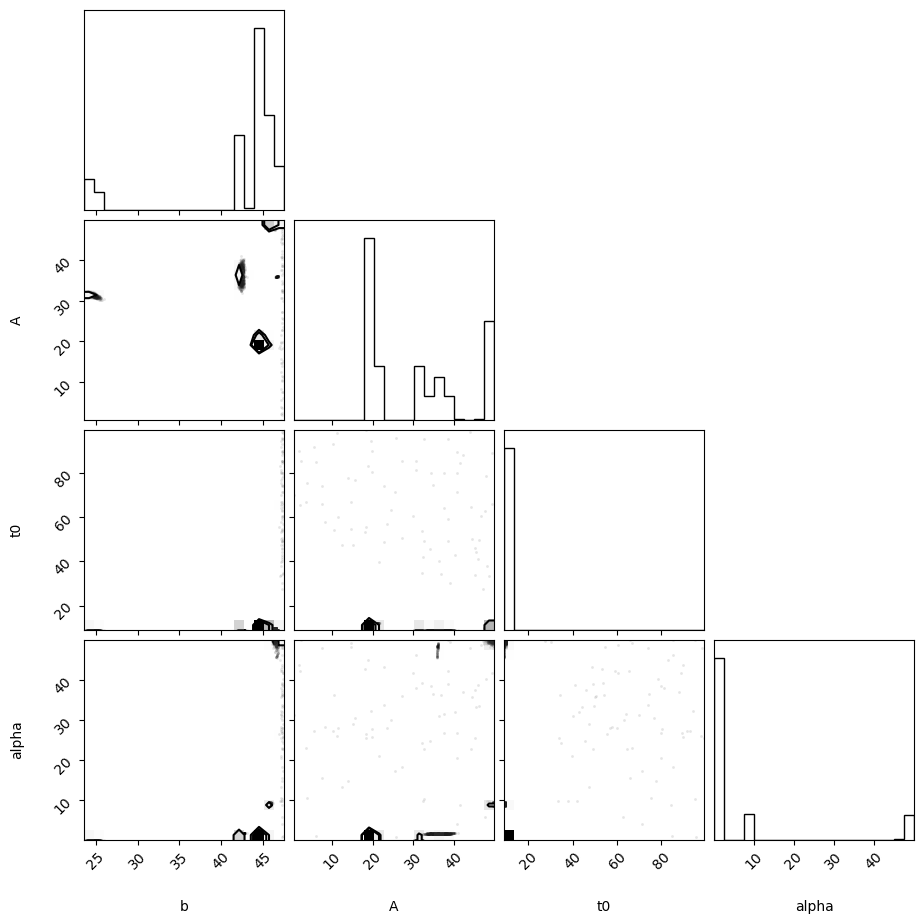

In [35]:
#corner plot
import corner
samples = sampler.get_chain(discard=burn, thin=thin, flat=True)



# optionally transform logalpha to alpha
samples_plot = samples.copy()
# samples_plot[:, 3] = np.exp(samples_plot[:, 3])  # convert logalpha to alpha

fig = corner.corner(samples_plot, labels=["b", "A", "t0", "alpha"])
plt.show()